# Rep. 3. Checkpoint 3. Limitaciones de Black-Scholes y modelos alternativos

* Gonzalo Cano
* Nicolas Martinez

Curtosis excess : 15.15   (normal = 0)
Asimetría       : -0.32    (normal = 0)


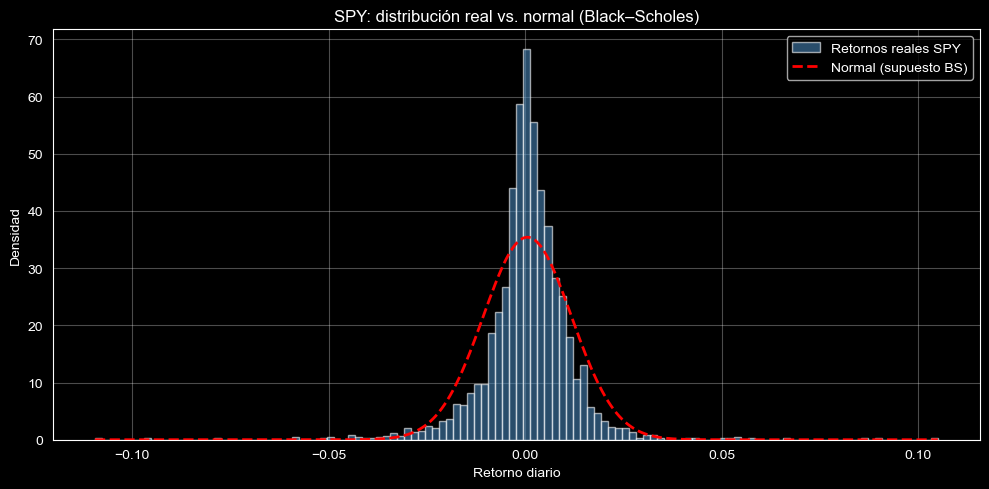

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

data     = yf.Ticker('SPY').history(period='10y')['Close']
retornos = data.pct_change().dropna()

print(f"Curtosis excess : {kurtosis(retornos):.2f}   (normal = 0)")
print(f"Asimetría       : {skew(retornos):.2f}    (normal = 0)")

x = np.linspace(retornos.min(), retornos.max(), 300)
plt.figure(figsize=(10, 5))
plt.hist(retornos, bins=120, density=True, alpha=0.6,
         color='steelblue', label='Retornos reales SPY')
plt.plot(x, norm.pdf(x, retornos.mean(), retornos.std()),
         'r--', linewidth=2, label='Normal (supuesto BS)')
plt.xlabel('Retorno diario')
plt.ylabel('Densidad')
plt.title('SPY: distribución real vs. normal (Black–Scholes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Modelo de Heston

El modelo de Heston relaja el supuesto de volatilidad constante de Black-Scholes al hacer que la varianza siga su propio proceso estocástico (proceso CIR). Esto genera distribuciones con colas más gruesas y asimetría negativa, capturando mejor el comportamiento real de los mercados.

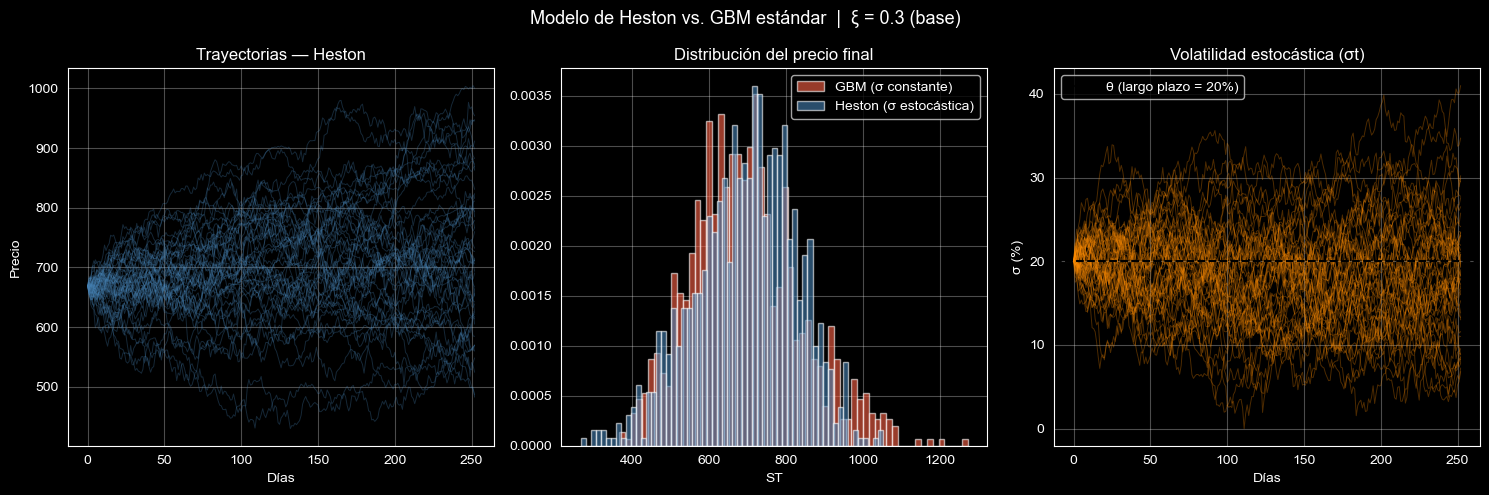

In [2]:
def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v

# Parámetros base
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi    = 0.3       # vol of vol (parámetro base)
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

# GBM de referencia (se reutilizará en todas las comparaciones)
sigma_const = 0.20
dt = T / N
np.random.seed(99)
Z  = np.random.randn(M, N)
S_gbm = np.zeros((M, N + 1))
S_gbm[:, 0] = S0
for t in range(1, N + 1):
    S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
        (mu - 0.5 * sigma_const**2) * dt + sigma_const * np.sqrt(dt) * Z[:, t-1]
    )

# --- Gráfica base: GBM vs Heston (ξ = 0.3) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(50):
    axes[0].plot(S_heston[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM (σ constante)')
axes[1].hist(S_heston[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for i in range(50):
    axes[2].plot(np.sqrt(v_heston[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo = {np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Modelo de Heston vs. GBM estándar  |  ξ = 0.3 (base)', fontsize=13)
plt.tight_layout()
plt.show()

### Variaciones de ξ (vol of vol) en el modelo de Heston

Se prueba con ξ = 0.1, ξ = 0.4 y ξ = 0.9 para observar cómo el parámetro de volatilidad de la volatilidad modifica la dispersión de trayectorias y la forma de la distribución final.

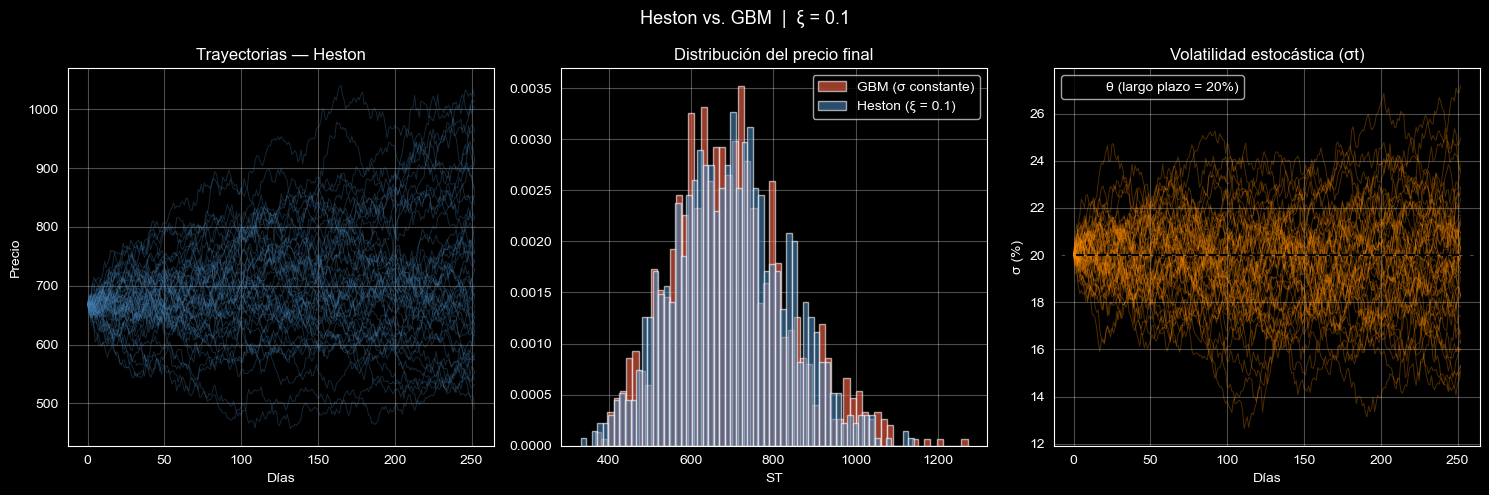

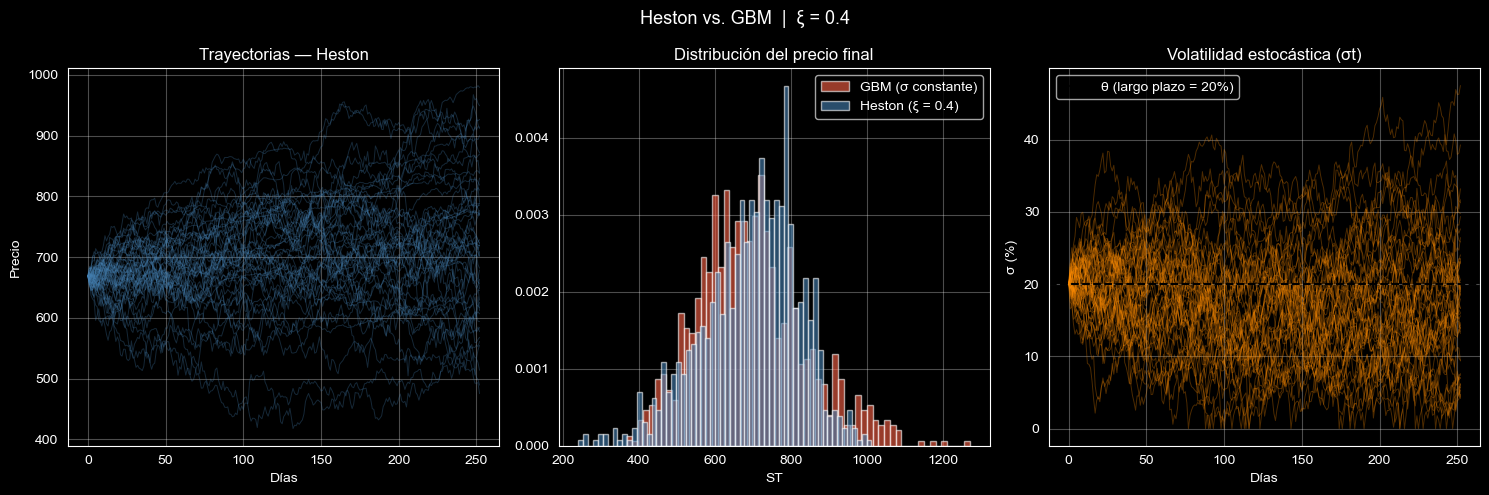

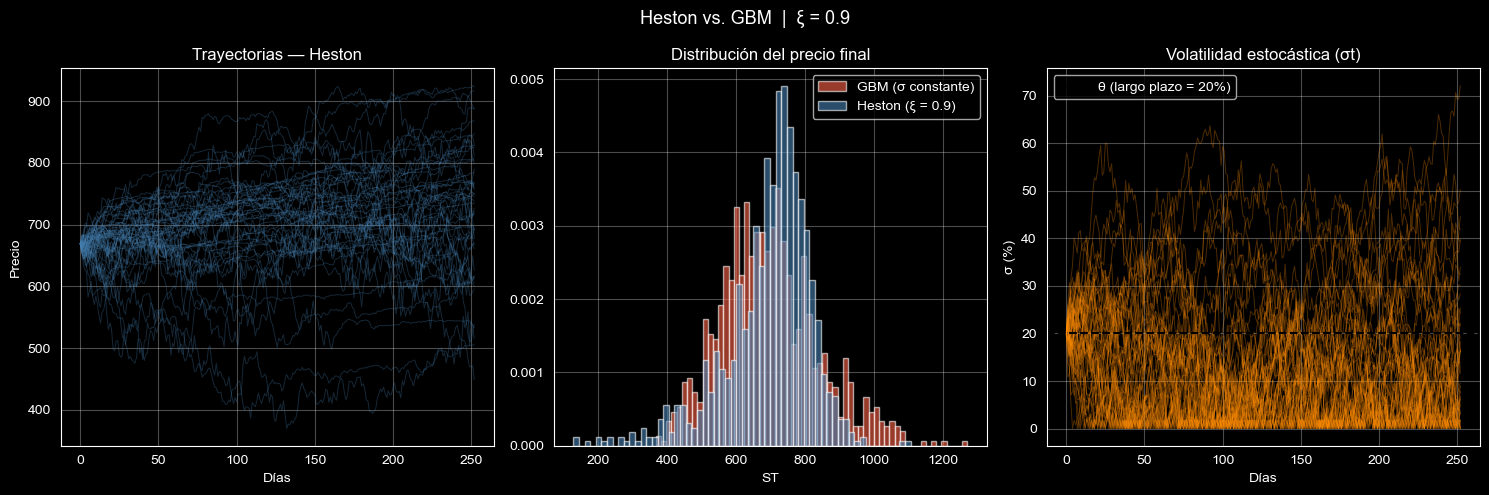

In [3]:
xi_valores = [0.1, 0.4, 0.9]

for xi_val in xi_valores:
    S_h, v_h = simular_heston(S0, v0, mu, kappa, theta, xi_val, rho, T, N, M)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i in range(50):
        axes[0].plot(S_h[i], alpha=0.3, linewidth=0.7, color='steelblue')
    axes[0].set_title('Trayectorias — Heston')
    axes[0].set_xlabel('Días')
    axes[0].set_ylabel('Precio')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(S_gbm[:, -1], bins=60, density=True, alpha=0.6,
                 color='tomato', label='GBM (σ constante)')
    axes[1].hist(S_h[:, -1],   bins=60, density=True, alpha=0.6,
                 color='steelblue', label=f'Heston (ξ = {xi_val})')
    axes[1].set_title('Distribución del precio final')
    axes[1].set_xlabel('ST')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    for i in range(50):
        axes[2].plot(np.sqrt(v_h[i]) * 100, alpha=0.3,
                     linewidth=0.7, color='darkorange')
    axes[2].axhline(np.sqrt(theta) * 100, color='black',
                    linestyle='--', label=f'θ (largo plazo = {np.sqrt(theta)*100:.0f}%)')
    axes[2].set_title('Volatilidad estocástica (σt)')
    axes[2].set_xlabel('Días')
    axes[2].set_ylabel('σ (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'Heston vs. GBM  |  ξ = {xi_val}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Modelo de Merton (Jump-Diffusion)

El modelo de Merton agrega saltos abruptos al proceso de precios mediante un proceso de Poisson. Esto genera trayectorias con discontinuidades y distribuciones con colas más gruesas y mayor asimetría negativa que el GBM puro, capturando eventos extremos como crashes o noticias inesperadas.

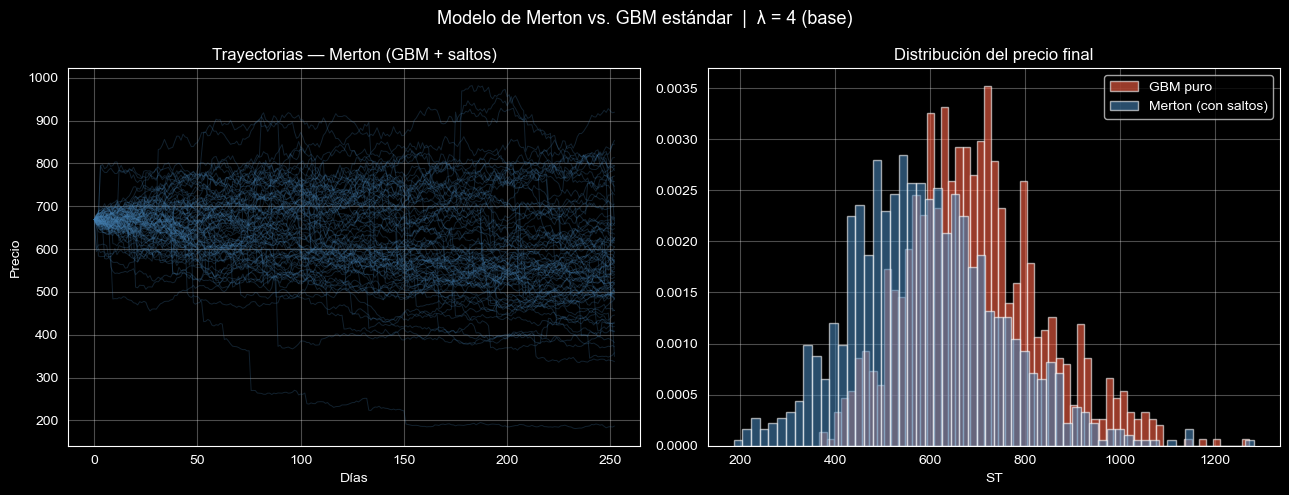

In [4]:
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos (Poisson)
        n_saltos  = np.random.poisson(lam * dt, M)
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

# Parámetros base
mu_m    = 0.042
sigma_m = 0.15
lam     = 4        # ~4 saltos por año (parámetro base)
mu_j    = -0.05    # saltos promedio de -5%
sigma_j = 0.10

S_merton = simular_merton(S0, mu_m, sigma_m, lam, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i in range(80):
    axes[0].plot(S_merton[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM puro')
axes[1].hist(S_merton[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Modelo de Merton vs. GBM estándar  |  λ = 4 (base)', fontsize=13)
plt.tight_layout()
plt.show()

### Variaciones de λ (intensidad de saltos) en el modelo de Merton

Se prueba con λ = 1, λ = 4 y λ = 15 para observar cómo la frecuencia de saltos afecta la estructura de las trayectorias y la forma de la distribución final.

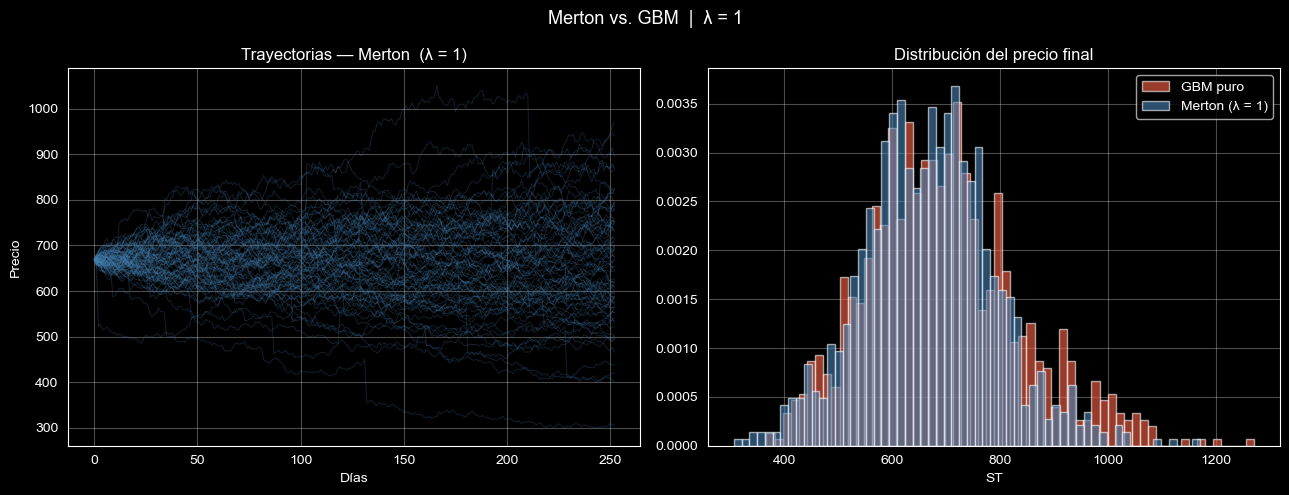

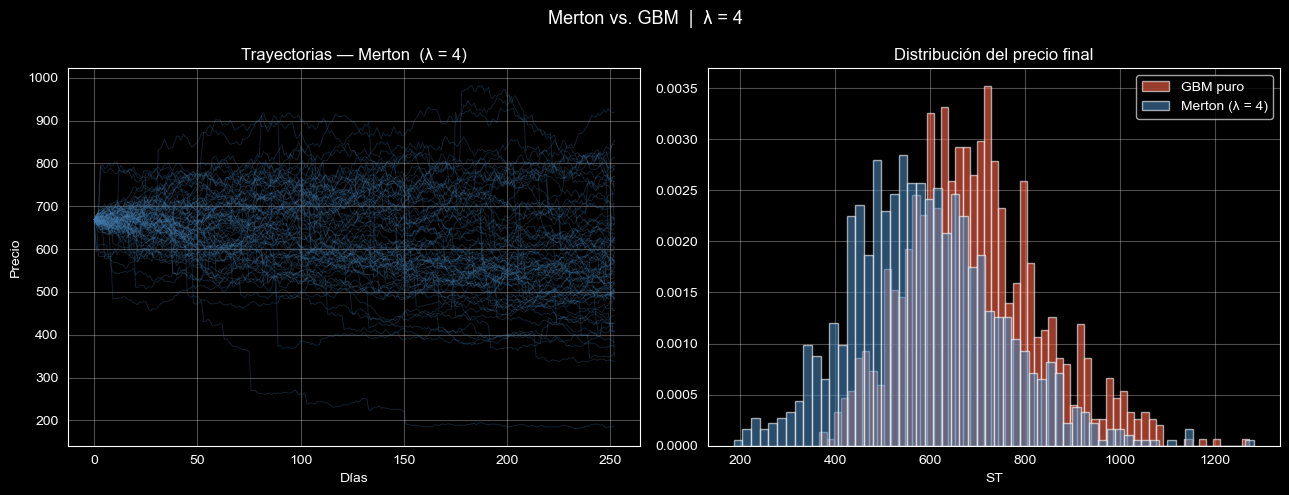

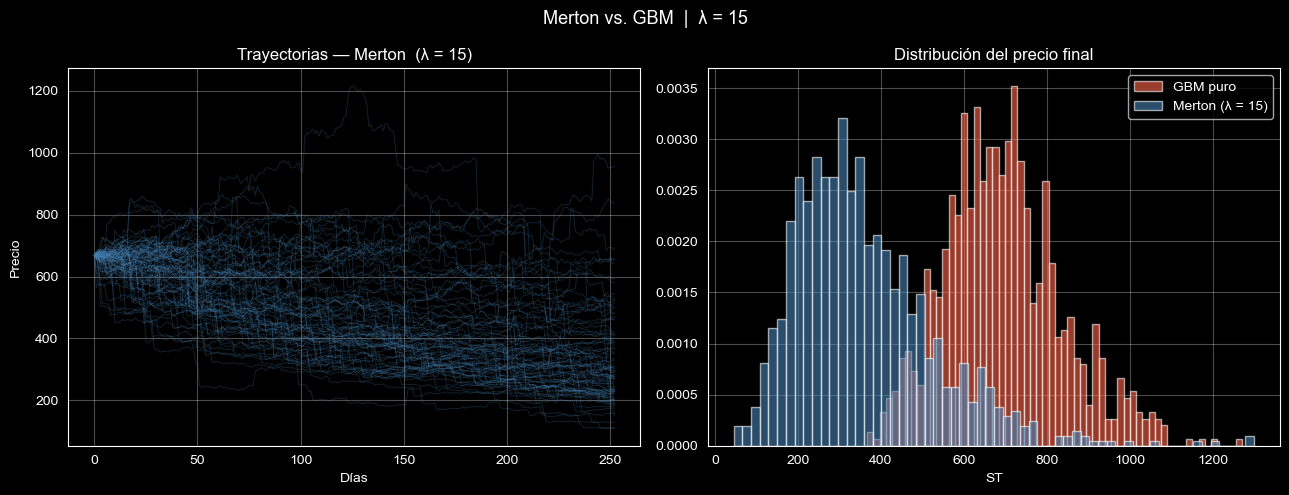

In [5]:
lambda_valores = [1, 4, 15]

for lam_val in lambda_valores:
    S_m = simular_merton(S0, mu_m, sigma_m, lam_val, mu_j, sigma_j, T, N, M)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for i in range(80):
        axes[0].plot(S_m[i], alpha=0.25, linewidth=0.7, color='steelblue')
    axes[0].set_title(f'Trayectorias — Merton  (λ = {lam_val})')
    axes[0].set_xlabel('Días')
    axes[0].set_ylabel('Precio')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(S_gbm[:, -1], bins=60, density=True, alpha=0.6,
                 color='tomato', label='GBM puro')
    axes[1].hist(S_m[:, -1],   bins=60, density=True, alpha=0.6,
                 color='steelblue', label=f'Merton (λ = {lam_val})')
    axes[1].set_title('Distribución del precio final')
    axes[1].set_xlabel('ST')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Merton vs. GBM  |  λ = {lam_val}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Preguntas de análisis

---

### 1. En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?

Aumentar ξ amplifica la incertidumbre sobre la propia volatilidad: la varianza salta más lejos de su nivel de largo plazo θ y permanece más tiempo alejada antes de revertir. Sobre la **distribución del precio final**, esto ensancha las colas y aumenta la curtosis (distribución más leptocúrtica), es decir, la distribución se vuelve más dispersa y con eventos extremos más frecuentes que en el GBM.

Sobre el **skew**, el efecto se potencia porque la correlación negativa ρ = −0.7 ya existe: cuando el precio cae, la volatilidad sube, y con un ξ alto esa subida es más pronunciada. Esto empuja más masa de probabilidad hacia precios bajos y produce una asimetría negativa más pronunciada (cola izquierda más gruesa). En términos de volatilidad implícita, esto se traduce en un *volatility skew* más pronunciado: las opciones put OTM se encarecen más relativamente que las call OTM.

---

### 2. En la simulación de Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias? ¿Y la distribución final?

Con λ = 10 (10 saltos esperados por año vs. 4), los saltos ocurren aproximadamente cada 36 días en lugar de cada 90. En las **trayectorias** esto se nota claramente: hay más discontinuidades visibles, el precio "salta" con mayor frecuencia y las trayectorias se ven más irregulares y accidentadas. Con saltos negativos dominantes (μ_j = −5%), muchas simulaciones acumulan varios choques a la baja durante el año.

En la **distribución final**, el resultado es una cola izquierda más gruesa y una distribución más asimétrica negativamente. La media se desplaza hacia la izquierda (el activo pierde valor esperado por los saltos negativos) y la curtosis aumenta. La distribución se parece cada vez menos a la log-normal de BS y más a una mezcla de distribuciones con masa concentrada en escenarios adversos.

---

### 3. Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM? ¿Por qué?

Black-Scholes **subestima** el precio de un put muy OTM (*out-of-the-money*).

La razón es que un put OTM solo tiene valor si el precio del subyacente cae mucho antes del vencimiento. BS asume una distribución log-normal con colas relativamente delgadas, por lo que asigna muy poca probabilidad a caídas extremas. En la realidad, los mercados exhiben *fat tails* (colas más gruesas) y asimetría negativa: los crashes ocurren con mayor frecuencia de lo que BS predice.

Al subestimar la probabilidad de esos escenarios de cola izquierda, BS calcula que el put tiene pocas chances de terminar ITM y le asigna un precio bajo. En la práctica, esos puts valen más de lo que BS dice, lo que es precisamente por qué existe el *volatility skew* en el mercado real: los puts OTM cotizan con mayor volatilidad implícita que lo que BS justificaría con una sola σ constante.

---

### 4. Merton asume que los saltos son predecibles en frecuencia (λ constante). ¿Qué limitación tiene eso en la práctica?

Asumir λ constante implica que los saltos llegan a una tasa uniforme a lo largo del tiempo, como si la probabilidad de un crash fuera la misma en todo momento. En la práctica esto no se sostiene por varias razones:

- **Clustering de eventos**: Los crashes y shocks tienden a ocurrir en rachas (crisis financieras, pandemias, quiebras en cadena). El modelo no captura que después de un salto la probabilidad de otro salto es mayor.
- **Regímenes de mercado**: La intensidad de saltos varía con el régimen económico. En períodos de estrés sistémico, λ es mucho más alta que en períodos tranquilos.
- **λ no observable**: La frecuencia real de saltos no puede estimarse directamente; depende de la definición de "salto" y del horizonte de observación, lo que hace difícil calibrar el modelo de forma robusta.
- **Endogeneidad**: Los propios participantes del mercado reaccionan a los saltos y modifican el comportamiento del activo, algo que un λ fijo no puede capturar.

---

### 5. ¿Por qué crees que BS sigue siendo el estándar de cotización a pesar de que Heston y Merton son más precisos?

Hay varias razones prácticas que explican la persistencia de BS como lenguaje de mercado:

1. **Simplicidad y velocidad**: BS tiene fórmula cerrada, corre instantáneamente y puede recalibrarse en tiempo real. Heston requiere transformadas de Fourier y Merton requiere sumas de series; ambos son más costosos computacionalmente.

2. **Un parámetro unificador**: La volatilidad implícita de BS funciona como un *lenguaje común* entre traders. Aunque todos saben que la superficie de vol implica que BS está "mal", cotizan en términos de vol implícita porque es un número que todos interpretan igual.

3. **Cobertura dinámica**: BS ofrece deltas y griegas analíticas con las que los traders hacen *hedging* dinámico. Con modelos más complejos, las griegas son más difíciles de calcular y la cobertura práctica se vuelve menos intuitiva.

4. **La superficie de volatilidad como corrección**: En la práctica, los traders no usan una sola σ; usan una superficie de volatilidad implícita que varía por strike y vencimiento. Esto esencialmente "corrige" las limitaciones de BS de manera ad hoc, sin necesidad de cambiar el modelo subyacente.

5. **Riesgo regulatorio y de modelo**: Adoptar un modelo más complejo introduce riesgo de modelo adicional. BS es bien entendido, auditado y aceptado por reguladores, lo que reduce el riesgo operacional y legal.